# Multi-layer neural networks
## Feed-forward model
### Activation functions

In [1]:
import numpy as np

# Sigmoid activation function: outputs values between 0 and 1
sigmoid = lambda z: 1 / (1 + np.exp(-z))

# Rectified linear unit (ReLU): outputs input if positive, zero otherwise
relu = lambda z: np.maximum(0, z)

# Heaviside step function: binary output based on input sign
jump = lambda z: np.where(z > 0, 1.0, 0.0)

### Single-layer activation

In [2]:
def activate_layer(
    input_data: np.ndarray,
    weight_matrix: np.ndarray,
    bias_vector: np.ndarray,
    activation: str = 'tanh') -> np.ndarray:
    """
    Activate a single layer for either single input or batch of inputs.
    Return the output of the layer.
    """
    # Handle single input vs batch input with appropriate broadcasting
    if input_data.ndim == 1:
        # Single input: standard matrix-vector multiplication
        z = weight_matrix @ input_data + bias_vector
    else:
        # Batch input: matrix-batch multiplication with broadcasting
        z = weight_matrix @ input_data + bias_vector[:, np.newaxis]

    # Apply specified activation function
    if activation == 'linear':
        return z
    elif activation == 'tanh':
        return np.tanh(z)
    elif activation == 'sigmoid':
        return sigmoid(z)
    elif activation == 'relu':
        return relu(z)
    elif activation == 'jump':
        return jump(z)
    else:
        raise ValueError(f'Unsupported activation function: {activation}')

### Multi-layer activation

In [3]:
from typing import List

def activate_network(
    input_data: np.ndarray,
    weight_matrices: List[np.ndarray],
    bias_vectors: List[np.ndarray],
    activation: str = 'tanh') -> List[np.ndarray]:
    """
    Activate the whole network for either single input or batch of inputs.
    Return list containing all layer outputs (including input layer).
    """
    # Validate network architecture consistency
    num_layers = len(weight_matrices)
    if num_layers != len(bias_vectors):
        raise ValueError('The number of weight matrices and bias vectors do not match.')
    
    # Forward pass through all layers
    activated_layers = [input_data]
    for weight_matrix, bias_vector in zip(weight_matrices, bias_vectors):
        layer_output = activate_layer(activated_layers[-1], weight_matrix, bias_vector, activation)
        activated_layers.append(layer_output)
    
    return activated_layers

def network_output(
    input_data: np.ndarray,
    weight_matrices: List[np.ndarray],
    bias_vectors: List[np.ndarray],
    activation: str = 'tanh') -> np.ndarray:
    """
    Compute network output for either single input or batch of inputs.
    Return only the final output layer.
    """
    # Get final layer output from full network activation
    return activate_network(input_data, weight_matrices, bias_vectors, activation)[-1]

### Test

In [4]:
# Define network architecture: input -> hidden -> output
dims = [2, 4, 2]

# Initialize network parameters with fixed seed
np.random.seed(42)
bias_vectors = [np.random.randn(dims[i]) for i in range(1, len(dims))]
weight_matrices = [np.random.randn(dims[i], dims[i - 1]) for i in range(1, len(dims))]

# Test single input forward pass
single_input = np.array([0.2, 0.4])
single_output = network_output(single_input, weight_matrices, bias_vectors, 'tanh')

# Test batch input forward pass
batch_input = np.array([[0.2, 0.1], [0.4, 0.5]])
batch_output = network_output(batch_input, weight_matrices, bias_vectors, 'sigmoid')

# Display results for comparison
print(f'Input vector:\n {single_input}')
print(f'Output using tanh activation:\n {single_output}')
print(f'Input batch:\n {batch_input}')
print(f'Output batch using sigmoid activation:\n {batch_output}')

Input vector:
 [0.2 0.4]
Output using tanh activation:
 [-0.94316984 -0.52224503]
Input batch:
 [[0.2 0.1]
 [0.4 0.5]]
Output batch using sigmoid activation:
 [[0.10019244 0.09995236]
 [0.28717069 0.28491365]]


### Output visualization

In [5]:
import matplotlib.pyplot as plt

# Set global plot styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 7
plt.rcParams['figure.dpi'] = 300

def visualize_output(
    weight_matrices: List[np.ndarray],
    bias_vectors: List[np.ndarray],
    activation: str = 'tanh',
    input_range: List[float] = [-5.0, 5.0, -5.0, 5.0],
    points: int = 300
    ) -> plt.Figure:
    """
    Visualize network with 2D input and 2D output.
    Return heatmap plot of both output dimensions.
    """
    # Validate network dimensions for 2D visualization
    input_dim = weight_matrices[0].shape[1]
    output_dim = weight_matrices[-1].shape[0]
    if input_dim != 2:
        raise ValueError('The input is not two-dimensional.')
    elif output_dim != 2:
        raise ValueError('The output is not two-dimensional.')
    
    # Validate network architecture consistency
    network_dims = [W.shape[0] for W in weight_matrices]
    bias_dims = [b.shape[0] for b in bias_vectors]
    if network_dims != bias_dims:
        raise ValueError('Weight and bias dimensions do not match.')

    # Create 2D input grid
    x1_range = np.linspace(input_range[0], input_range[1], points)
    x2_range = np.linspace(input_range[2], input_range[3], points)

    X1, X2 = np.meshgrid(x1_range, x2_range)
    input_points = np.vstack([X1.ravel(), X2.ravel()])

    # Compute network outputs across grid
    outputs_raw = network_output(input_points, weight_matrices, bias_vectors, activation)
    outputs = [outputs_raw[0].reshape(X1.shape), outputs_raw[1].reshape(X2.shape)]
    titles = ['Output 1', 'Output 2']

    # Configure plot settings
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 7
    plt.rcParams['figure.dpi'] = 300
    
    # Create side-by-side heatmaps
    fig, axes = plt.subplots(1, 2, figsize = (10, 4))
    for ax, output, title in zip(axes, outputs, titles):
        im = ax.imshow(output, extent = input_range, origin = 'lower', cmap = 'copper')
        ax.set_title(title)
        ax.set_xlabel('$x_1$')
        ax.set_ylabel('$x_2$')
        fig.colorbar(im, ax = ax)
    
    plt.tight_layout()
    plt.close()
    return fig

### Test

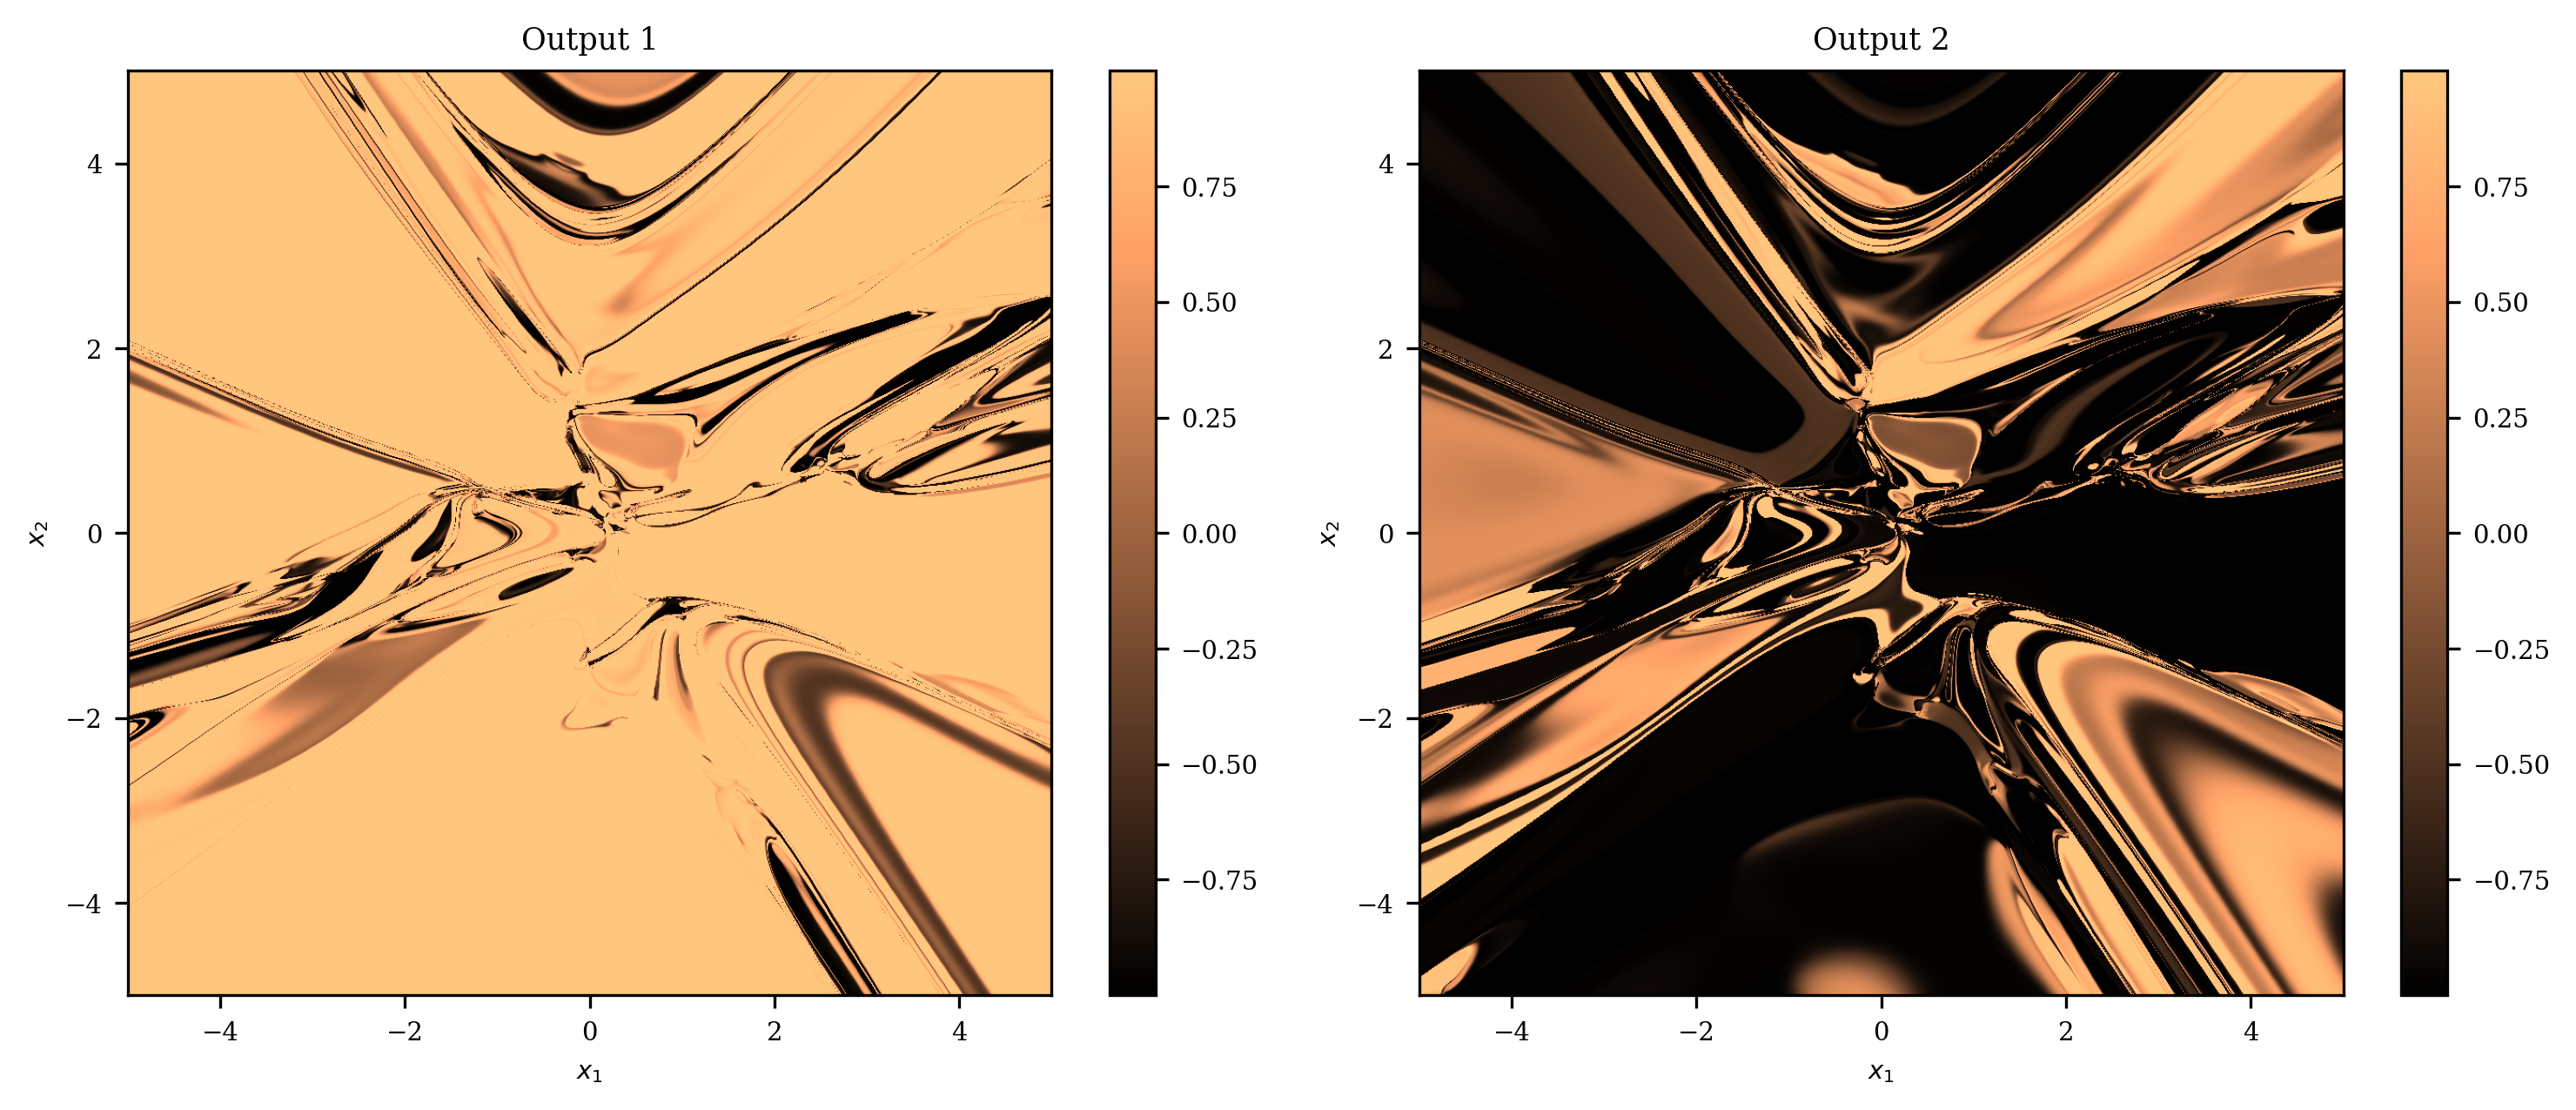

In [6]:
# Define deep network architecture parameters
num_layers = 15
layer_width = 15
input_dim, output_dim = 2, 2

# Create network dimensions: input -> hidden layers -> output
dims = [input_dim] + [layer_width] * num_layers + [output_dim]

# Initialize network parameters with fixed seed
np.random.seed(42)
bias_vectors = [np.random.randn(dims[i]) for i in range(1, len(dims))]
weight_matrices = [np.random.randn(dims[i], dims[i-1]) for i in range(1, len(dims))]

# Generate high-resolution visualization of network output
visualize_output(weight_matrices, bias_vectors, points = 1000)